In [19]:
import numpy as np
import matplotlib.pyplot as plt
from behavex.models.hmm_trainer import HiddenMarkovModelTrainer
plt.switch_backend("module://matplotlib_inline.backend_inline")

In [57]:
latents = np.load("/Users/thomasbush/Documents/ML/rearing/session_latents.npy")
model = HiddenMarkovModelTrainer.load("/Users/thomasbush/Documents/ML/rearing/hhm_session_1.pkl")


In [55]:
model.model.transmat_

array([[8.56980988e-001, 1.17909929e-001, 9.44862665e-004,
        4.74424297e-003, 9.48332562e-004, 5.67560726e-003,
        0.00000000e+000, 1.27960374e-002],
       [5.56259773e-002, 8.46199921e-001, 5.44726527e-237,
        2.21627315e-002, 0.00000000e+000, 2.22219124e-002,
        0.00000000e+000, 5.37894581e-002],
       [2.08958721e-003, 1.34994991e-238, 9.47154370e-001,
        1.19266147e-003, 1.47948306e-002, 6.39746438e-004,
        1.50180543e-003, 3.26269993e-002],
       [1.98385327e-002, 7.80833102e-003, 6.28312388e-003,
        9.06280462e-001, 6.24314683e-003, 3.66293908e-003,
        4.35364241e-002, 6.34703992e-003],
       [1.34454348e-002, 0.00000000e+000, 2.40532281e-002,
        5.17552229e-003, 9.29914621e-001, 2.58510642e-003,
        6.21679769e-003, 1.86092901e-002],
       [2.20348748e-002, 7.77817572e-003, 1.31763205e-003,
        1.36088231e-002, 7.12468311e-003, 9.15076467e-001,
        2.78408220e-002, 5.21852175e-003],
       [5.07292189e-003, 0.0000000

In [84]:
sticky = 30.0
A = model.get_transition_matrix().copy()
A_sticky = A + np.eye(len(A)) * sticky
A_sticky /= A_sticky.sum(axis=1, keepdims=True)
model.model.transmat_ = A_sticky


In [85]:
states, log_probs = model.decode_states([latents])

In [86]:
latents.shape[0] * 4 / 60 / 60

20.62222222222222

In [87]:
patch_len, fps = 4, 60
t = np.arange(len(states)) * patch_len / fps


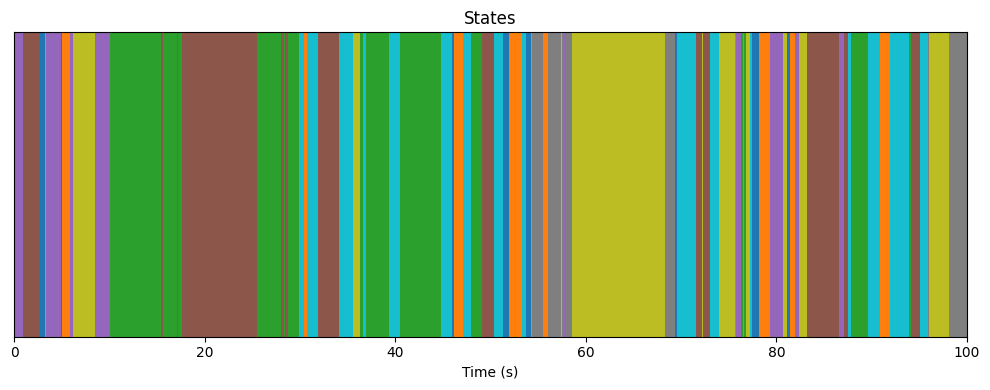

In [89]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(10, 4))
ax.imshow(states.astype(float)[None, :], aspect="auto", cmap="tab10",
            extent=[t[0], t[-1], 0, 1], vmin=0, vmax = model.n_states-1, interpolation="nearest")
ax.set_xlabel("Time (s)")
ax.set_yticks([])
ax.set_xlim(t[0], 100)
ax.set_title("States")
plt.tight_layout()
plt.show()